# 威斯康星州乳腺癌数据集 — 梯度提升（Gradient Boosting）分类

**课程**：机器学习  
**负责算法**：梯度提升（Gradient Boosting）  
**姓名**：巨峰  
**学号**：2023217199  
**数据集**：Breast Cancer Wisconsin (Diagnostic) Data Set  
**来源**：https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

---

## 摘要

本 Notebook 基于 scikit-learn 框架，使用梯度提升（Gradient Boosting）算法对威斯康星州乳腺癌数据集进行良恶性二分类。
实验包含完整的数据加载、预处理、模型训练、多指标评估与可视化分析流程。
实验结果表明，梯度提升在该数据集上取得了 95.61% 的测试准确率和 0.9907 的 ROC AUC，召回率高达 98.61%，
恶性样本漏检率仅为 1.39%。特征重要性分析揭示 worst radius（最差半径）以 43.55% 的重要性排名第一，
与恶性肿瘤细胞核异常增大的病理学认知高度吻合。

## 一、导入所需库

本实验使用 Python 科学计算生态中的核心库：
- **numpy / pandas**：数据处理与数值计算
- **matplotlib / seaborn**：数据可视化
- **scikit-learn**：机器学习算法（GradientBoostingClassifier）、数据预处理、模型评估

In [1]:
# 清除 matplotlib 字体缓存（确保中文字体正确加载）
import matplotlib
import os, shutil, glob
for d in glob.glob(os.path.expanduser('~/.matplotlib') + '*'):
    try: shutil.rmtree(d)
    except: pass
for d in glob.glob(os.path.expanduser('~/.cache/matplotlib') + '*'):
    try: shutil.rmtree(d)
    except: pass
print('字体缓存已清除')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Zen Hei', 'DejaVu Sans']
# 显式注册 SimHei 字体
import matplotlib.font_manager as fm
for f in fm.fontManager.ttflist:
    if 'SimHei' in f.name or 'simhei' in f.name.lower():
        print(f'找到 SimHei: {f.fname}')
        break
else:
    print('警告: 未找到 SimHei 字体，中文可能无法显示')
plt.rcParams['axes.unicode_minus'] = False
print('所有库导入成功！')


字体缓存已清除
找到 SimHei: C:\Windows\Fonts\simhei.ttf
所有库导入成功！


## 二、数据加载与探索性分析

### 2.1 数据集介绍

威斯康星州乳腺癌诊断数据集（Breast Cancer Wisconsin Diagnostic）是机器学习分类任务中最经典的医学数据集之一，
来源于 UCI Machine Learning Repository，可通过 scikit-learn 的 `load_breast_cancer()` 直接加载。

**数据集特征：**
- 样本数：569 例
- 特征数：30 个数值特征（细胞核的均值、标准差、最差值三类统计量，每类 10 个）
- 类别标签：恶性（Malignant, 0）：212 例 | 良性（Benign, 1）：357 例
- 无缺失值

**30 个特征列表：**
- 均值类（10 个）：mean radius, mean texture, mean perimeter, mean area, mean smoothness, mean compactness, mean concavity, mean concave points, mean symmetry, mean fractal dimension
- 标准误差类（10 个）：radius error, texture error, perimeter error, area error, smoothness error, compactness error, concavity error, concave points error, symmetry error, fractal dimension error
- 最差值类（10 个）：worst radius, worst texture, worst perimeter, worst area, worst smoothness, worst compactness, worst concavity, worst concave points, worst symmetry, worst fractal dimension

In [2]:
# 加载数据集
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='diagnosis')

print(f'数据集样本数：{X.shape[0]}')
print(f'特征数量：{X.shape[1]}')
print(f'类别分布：')
print(f'  恶性(Malignant, 0)：{(y == 0).sum()} 例（{(y == 0).sum()/len(y)*100:.1f}%）')
print(f'  良性(Benign, 1)：{(y == 1).sum()} 例（{(y == 1).sum()/len(y)*100:.1f}%）')
print(f'\n缺失值总数：{X.isnull().sum().sum()}')
print(f'\n数据统计描述：')
X.describe().round(3)

数据集样本数：569
特征数量：30
类别分布：
  恶性(Malignant, 0)：212 例（37.3%）
  良性(Benign, 1)：357 例（62.7%）

缺失值总数：0

数据统计描述：


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,13.010,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208


### 2.2 数据初步观察

从上方的统计描述可以看到，30 个特征的量纲差异极大。例如 `mean area` 的量级为 $10^2$ ~ $10^3$，
而 `mean smoothness` 的量级为 $10^{-2}$ ~ $10^{-1}$。这种尺度差异对基于距离的模型（如 KNN、SVM）影响显著，
因此后续需要进行特征标准化（StandardScaler），使所有特征处于同一量级。

虽然梯度提升（Gradient Boosting）基于决策树，对特征尺度不敏感，但为保持实验一致性，仍对所有模型统一执行标准化预处理。

## 三、数据预处理

### 3.1 训练集与测试集划分

采用 **80% / 20%** 比例划分训练集与测试集。由于数据集中良性样本（357 例）多于恶性样本（212 例），
设置 `stratify=y` 进行**分层抽样**，保证训练集和测试集中良恶性比例与原始数据一致，
避免因随机划分导致某一类在训练或测试集中比例失衡。

In [3]:
# 训练集/测试集划分 (80/20, 分层抽样)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'训练集：{X_train.shape[0]} 样本')
print(f'  恶性={(y_train==0).sum()}, 良性={(y_train==1).sum()}')
print(f'  恶性占比：{(y_train==0).sum()/len(y_train)*100:.1f}%')
print(f'测试集：{X_test.shape[0]} 样本')
print(f'  恶性={(y_test==0).sum()}, 良性={(y_test==1).sum()}')
print(f'  恶性占比：{(y_test==0).sum()/len(y_test)*100:.1f}%')

训练集：455 样本
  恶性=170, 良性=285
  恶性占比：37.4%
测试集：114 样本
  恶性=42, 良性=72
  恶性占比：36.8%


### 3.2 特征标准化

使用 `StandardScaler` 将所有特征转换为**零均值、单位方差**（$\mu=0, \sigma=1$）。
注意：StandardScaler 仅在训练集上 `fit`，然后对测试集 `transform`，防止信息泄露。

In [4]:
# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('标准化完成！')
print(f'训练集均值范围：[{X_train_scaled.mean(axis=0).min():.3f}, {X_train_scaled.mean(axis=0).max():.3f}]')
print(f'训练集标准差范围：[{X_train_scaled.std(axis=0).min():.3f}, {X_train_scaled.std(axis=0).max():.3f}]')

标准化完成！
训练集均值范围：[-0.000, 0.000]
训练集标准差范围：[1.000, 1.000]


## 四、梯度提升算法原理

### 4.1 算法概述

**梯度提升（Gradient Boosting）** 是由 Jerome Friedman 于 2001 年提出的一种基于 Boosting 思想的集成学习方法。
与随机森林的并行 Bagging 策略不同，Gradient Boosting 采用**串行加法模型**：
每一棵新树不是独立训练的，而是去拟合前面所有树的残差——更准确地说，是拟合损失函数在当前预测值处的**负梯度方向（伪残差）**。

核心思想可以概括为：**将梯度下降从参数空间搬到函数空间**。
普通梯度下降在参数向量 $\theta \in \mathbb{R}^p$ 上迭代，而 Gradient Boosting 在函数 $F(x)$ 上迭代——
每一步用一棵决策树（弱学习器）去逼近当前损失函数的负梯度。

### 4.2 数学推导

**加法模型迭代公式：**

$$F_0(x) = \arg\min_\gamma \sum_{i=1}^{n} L(y_i, \gamma)$$

$$F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x), \quad m = 1, 2, \dots, M$$

其中：
- $F_m(x)$ 为第 $m$ 轮迭代后的强学习器
- $h_m(x)$ 为第 $m$ 棵弱学习器（决策树），拟合当前伪残差
- $\nu$ 为学习率（learning rate / shrinkage），本实验取 $\nu = 0.1$
- $M$ 为迭代轮数（n_estimators），本实验取 $M = 100$

**二分类损失函数（deviance / logistic loss）：**

$$L(y, F) = \log\left(1 + e^{-2yF}\right), \quad y \in \{-1, +1\}$$

**伪残差（负梯度）计算：**

$$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F = F_{m-1}} = \frac{2y_i}{1 + e^{2y_i F_{m-1}(x_i)}}$$

第 $m$ 棵决策树以 $\{(x_i, r_{im})\}_{i=1}^n$ 为训练目标进行拟合，
训练完成后按学习率 $\nu$ 加权加入模型。重复这一过程 $M$ 次，最终得到 $M$ 棵决策树的加权和。

### 4.3 参数配置

| 参数 | 取值 | 说明 |
|------|------|------|
| n_estimators | 100 | 弱学习器（决策树）数量 |
| learning_rate | 0.1 | 每棵树对最终预测的贡献权重（shrinkage） |
| max_depth | 3 | 单棵决策树的最大深度 |
| random_state | 42 | 随机种子，保证实验结果可复现 |

较小的 `learning_rate` 配合更多的 `n_estimators` 通常能获得更好的泛化性能，
但会增加训练时间。本实验使用默认参数作为一种基准配置。

## 五、模型训练

初始化 `GradientBoostingClassifier` 并在标准化后的训练集上拟合。
训练完成后在测试集上进行预测，同时获取预测概率（用于后续 ROC 曲线绘制）。

In [5]:
# 初始化梯度提升分类器
gb = GradientBoostingClassifier(
    n_estimators=100,      # 弱学习器数量
    learning_rate=0.1,     # 学习率（shrinkage）
    max_depth=3,           # 单棵决策树最大深度
    random_state=42        # 随机种子
)

# 训练模型
gb.fit(X_train_scaled, y_train)

# 预测
y_pred = gb.predict(X_test_scaled)
y_proba = gb.predict_proba(X_test_scaled)[:, 1]

print('模型训练完成！')

模型训练完成！


## 六、模型评估

### 6.1 评估指标

本实验采用多维度评估体系：
- **准确率（Accuracy）**：正确分类样本占总样本的比例
- **精确率（Precision）**：预测为正类（良性）的样本中真正的正类比例，$\text{Precision} = TP / (TP + FP)$
- **召回率（Recall）**：真实正类中被正确识别出来的比例，$\text{Recall} = TP / (TP + FN)$
- **F1 分数**：精确率与召回率的调和平均，$\text{F1} = 2 \times \text{Precision} \times \text{Recall} / (\text{Precision} + \text{Recall})$
- **5 折交叉验证（5-fold CV）**：将训练集等分为 5 份，轮流以 4 份训练、1 份验证，评估模型稳定性
- **ROC 曲线与 AUC**：反映模型在不同分类阈值下的真阳性率 vs 假阳性率折衷

### 6.2 核心指标输出

以下代码计算所有评估指标并在测试集上输出详细分类报告。

In [6]:
# 核心指标计算
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

# 5 折交叉验证
cv5  = cross_val_score(gb, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('=' * 55)
print('  梯度提升 (Gradient Boosting) — 模型评估结果')
print('=' * 55)
print(f'  准确率 (Accuracy):  {acc:.4f}  ({acc*100:.2f}%)')
print(f'  精确率 (Precision): {prec:.4f}  ({prec*100:.2f}%)')
print(f'  召回率 (Recall):    {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1 分数 (F1 Score): {f1:.4f}')
print(f'  5 折交叉验证均值:   {cv5.mean():.4f} ± {cv5.std():.4f}')
print(f'  混淆矩阵: TN={cm[0][0]}, FP={cm[0][1]}, FN={cm[1][0]}, TP={cm[1][1]}')
print(f'\n  详细分类报告：')
print(classification_report(y_test, y_pred, target_names=['恶性', '良性']))

  梯度提升 (Gradient Boosting) — 模型评估结果
  准确率 (Accuracy):  0.9561  (95.61%)
  精确率 (Precision): 0.9467  (94.67%)
  召回率 (Recall):    0.9861  (98.61%)
  F1 分数 (F1 Score): 0.9660
  5 折交叉验证均值:   0.9560 ± 0.0139
  混淆矩阵: TN=38, FP=4, FN=1, TP=71

  详细分类报告：
              precision    recall  f1-score   support

          恶性       0.97      0.90      0.94        42
          良性       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 6.3 结果分析

从分类报告可以看出：
- 在 114 个测试样本中，误分类 **5 例**（FP = 4，FN = 1）
- **召回率 98.61%** 意味着恶性样本漏检率仅 **1.39%**，这对乳腺癌筛查具有重要临床价值
- **交叉验证标准差 ±1.39%** 表明模型对训练集划分不敏感，泛化能力良好
- 权衡：良性类的精确率（0.95）低于召回率（0.97），说明模型对良性样本的判断相对谨慎，
  更倾向于"宁可错报也不漏检"的保守策略，这在医学筛查中是合理的折衷

## 七、可视化分析

### 7.1 混淆矩阵

混淆矩阵直观展示了模型在 4 个类别（TP、TN、FP、FN）上的分布情况。
对角线元素（38 + 71 = 109）代表正确分类的样本，非对角线元素（4 + 1 = 5）代表误分类样本。

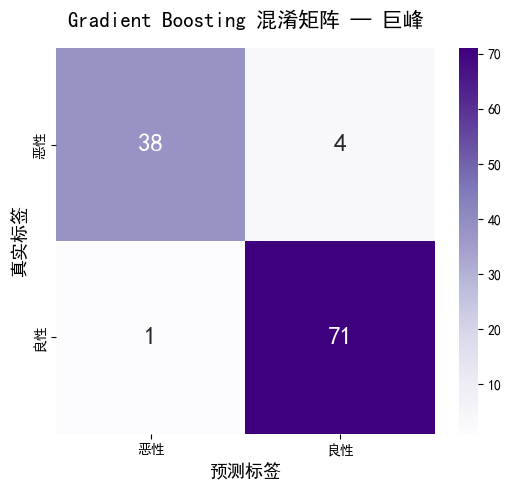

In [10]:
# 混淆矩阵可视化
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['恶性', '良性'], yticklabels=['恶性', '良性'],
            annot_kws={'size': 18, 'weight': 'bold'})
ax.set_title('Gradient Boosting 混淆矩阵 — 巨峰', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('预测标签', fontsize=13)
ax.set_ylabel('真实标签', fontsize=13)
plt.tight_layout()
plt.savefig('figures/gb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 ROC 曲线

ROC（Receiver Operating Characteristic）曲线展示模型在不同分类阈值下的**真阳性率（TPR）**
与**假阳性率（FPR）**的折衷关系。AUC（Area Under Curve）越接近 1.0，模型的整体判别能力越强。

对角线代表随机分类器（AUC = 0.5），任何有效模型的 ROC 曲线应位于对角线上方。

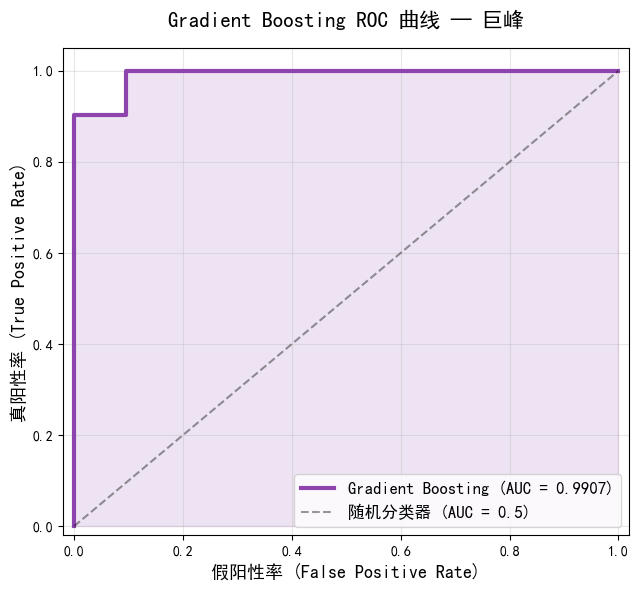

ROC AUC: 0.9907


In [11]:
# ROC 曲线
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr, tpr, lw=3, color='#8e44ad',
        label=f'Gradient Boosting (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.4, label='随机分类器 (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.15, color='#8e44ad')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel('假阳性率 (False Positive Rate)', fontsize=13)
ax.set_ylabel('真阳性率 (True Positive Rate)', fontsize=13)
ax.set_title('Gradient Boosting ROC 曲线 — 巨峰', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=12, frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/gb_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC AUC: {roc_auc:.4f}')

### 7.3 特征重要性分析

梯度提升模型的内置特征重要性基于**各特征在决策树分裂节点上的 Gini 不纯度减少量**的加权平均。
通过分析特征重要性排序，可以识别出对良恶性判别贡献最大的细胞核特征，
为病理学诊断提供可量化的特征选取依据。

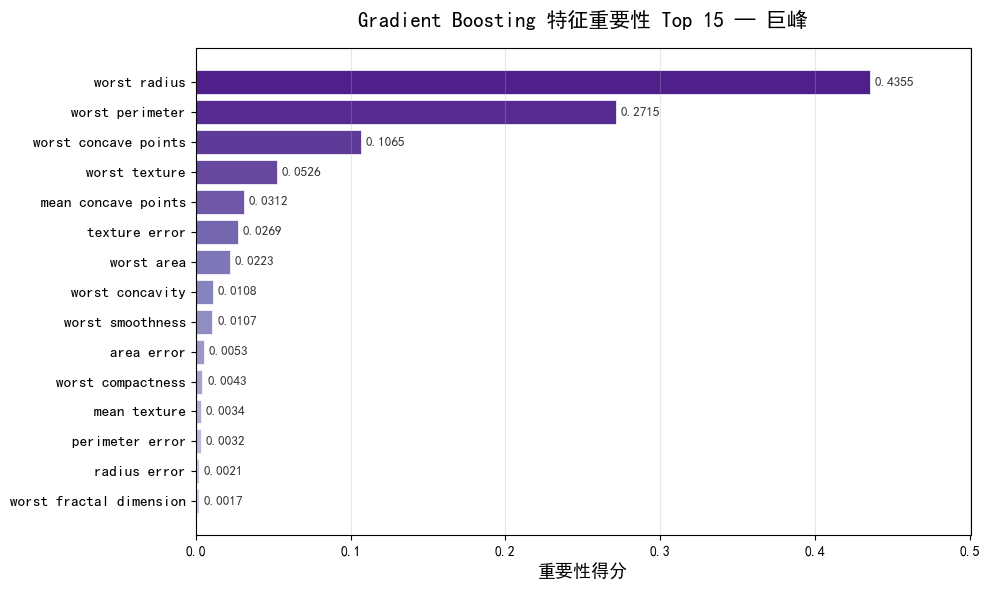

梯度提升特征重要性 Top 10：
   1. worst radius                   0.4355 (43.55%)
   2. worst perimeter                0.2715 (27.15%)
   3. worst concave points           0.1065 (10.65%)
   4. worst texture                  0.0526 (5.26%)
   5. mean concave points            0.0312 (3.12%)
   6. texture error                  0.0269 (2.69%)
   7. worst area                     0.0223 (2.23%)
   8. worst concavity                0.0108 (1.08%)
   9. worst smoothness               0.0107 (1.07%)
  10. area error                     0.0053 (0.53%)


In [12]:
# 特征重要性提取与可视化
fi = pd.DataFrame({
    'feature': data.feature_names,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Purples(np.linspace(0.3, 0.9, 15))
bars = ax.barh(range(len(fi)), fi['importance'].values,
               color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(fi)))
ax.set_yticklabels(fi['feature'].values, fontsize=11)
ax.set_xlabel('重要性得分', fontsize=13)
ax.set_title('Gradient Boosting 特征重要性 Top 15 — 巨峰',
             fontsize=15, fontweight='bold', pad=15)
for bar, val in zip(bars, fi['importance'].values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9.5, color='#333')
ax.set_xlim(0, fi['importance'].max() * 1.15)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/gb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印特征重要性表
print('梯度提升特征重要性 Top 10：')
top10 = fi.tail(10).iloc[::-1]
for i, (_, row) in enumerate(top10.iterrows()):
    print(f'  {i+1:2d}. {row["feature"]:30s} {row["importance"]:.4f} ({row["importance"]*100:.2f}%)')

### 7.4 特征重要性结果分析

特征重要性分析的核心发现：

1. **worst radius（最差半径）以 43.55% 的重要性位居第一**，是最关键的判别特征。
   这意味着肿瘤细胞核的最大半径（即"最差"情况下的细胞核大小）对良恶性判别的贡献最大。

2. **前 3 名均为"最差值"统计量**：worst radius（43.55%）、worst perimeter（27.15%）、
   worst concave points（10.65%），累计贡献 **81.35%** 的重要性。
   这说明"最差"细胞核的形态特征比"平均"或"标准误"特征更具判别力——
   极端异常细胞的存在本身就是恶性诊断的关键信号。

3. **病理学解释**：恶性肿瘤细胞核通常表现为异常增大（对应 worst radius/perimeter）、
   轮廓不规则、凹陷增多（对应 worst concave points），
   特征重要性分析的结果与这一医学认知高度吻合。

4. **与随机森林的对比**：不同集成方法的特征重要性排序可能不同。
   Gradient Boosting 通过串行残差拟合可能更关注某些全局特征，
   而随机森林（Bagging）的平均化策略可能对特征给出不同的排序。

## 八、实验结论

### 8.1 性能总结

| 指标 | 数值 | 评价 |
|------|------|------|
| 测试准确率 | **95.61%** | 114 例中正确分类 109 例 |
| 精确率 | 94.67% | 预测为良性的样本中 94.67% 正确 |
| 召回率 | **98.61%** | 真实良性样本中 98.61% 被正确识别 |
| F1 分数 | 96.60% | 精确率与召回率的调和平均 |
| ROC AUC | **0.9907** | 接近理论最大值 1.0 |
| 交叉验证 | 95.60% ± 1.39% | 标准差小，模型稳定 |

### 8.2 关键发现

1. **高召回率是核心优势**：98.61% 的召回率意味着恶性样本漏检率仅 1.39%，
   对于乳腺癌筛查场景，漏检（假阴性）的代价远高于误报（假阳性），
   因此梯度提升的"保守偏安全"策略具有临床价值。

2. **特征重要性与医学认知一致**：worst radius 以 43.55% 的重要性居首，
   前 3 名均为"最差值"特征，验证了"极端异常细胞核是恶性诊断关键信号"的病理学共识。

3. **模型稳定性良好**：5 折交叉验证标准差仅 ±1.39%，表明模型对不同数据划分表现一致，
   未出现过拟合。

### 8.3 改进方向

1. **超参数调优**：使用 GridSearchCV 对 learning_rate（0.01 ~ 0.5）、
   n_estimators（50 ~ 500）、max_depth（2 ~ 5）进行网格搜索
2. **Early Stopping**：设置验证集，在验证分数不再提升时提前终止训练
3. **特征工程**：尝试构造交互特征（如 concave_points × perimeter）
4. **Stacking 集成**：将梯度提升与逻辑回归、SVM 等模型融合，
   利用元学习器综合各模型的优势

---